# Sensitivity of the fit to the weighting scheme and to the assumed
# premature-termination fraction

**Reviewer #2, points 2 and 3.** Two fitting choices are questioned:

* genomic (TSS dxChIP-seq) residuals carry a **3× weight** relative to imaging
  residuals, and the ARMC5 imaging series is inverse-variance weighted and
  renormalised to a mean weight of 3;
* **80% of promoter-proximal Pol II terminates prematurely** at $T=1$, imposed
  as an external constraint on the flux ratio
  $J_{P\to N}/J_{P\to E}=f/(1-f)=4$.

Here each choice is varied over a wide range, the model is re-fitted from scratch
in every case, and the quantities the manuscript's conclusions depend on are
re-derived: the two saturation levels at $T=1$, the lower edge of the buffering
range, and the local sensitivity $S=d\ln E^*/d\ln T$ at $T=1$ ($S=0$ perfect
buffering, $S=1$ no buffering).

In [1]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())
os.environ.setdefault("POLII_DATA", "../data")   # run from activity_homeostasis/
import polii_model as pm

plt.rcParams.update({"font.family": "Arial", "font.size": 8, "figure.dpi": 150,
                     "savefig.dpi": 300, "axes.spines.top": False,
                     "axes.spines.right": False})

data = pm.load_data()
REF = pm.fit(data, n_starts=40, seed=7)["params"]      # published settings
print("reference fit:", dict(zip(pm.PARAM_NAMES, np.round(REF, 4))))
print(pd.Series(pm.summarise(REF, data)).round(3).to_string())

reference fit: {'k_pn': np.float64(4.1911), 'Vmax_pe': np.float64(0.3385), 'Km_pe': np.float64(0.0307), 'Vmax_np': np.float64(2.749), 'Km_np': np.float64(0.3189)}
k_pn         4.191
Vmax_pe      0.338
Km_pe        0.031
Vmax_np      2.749
Km_np        0.319
N0           0.401
P0           0.292
E0           0.306
s_np_T0.5    0.271
s_pe_T0.5    0.788
s_np_T0.7    0.402
s_pe_T0.7    0.863
s_np_T1.0    0.557
s_pe_T1.0    0.905
T_low        0.685
T_high         NaN
S_T1         0.089
cost         0.002


In [2]:
def run(label, n_starts=10, **kw):
    """Refit under fitting choices `kw` and summarise the derived quantities."""
    r = pm.fit(data, n_starts=n_starts, seed=11, x0=REF, **kw)
    s = pm.summarise(r["params"], data, **kw)
    s["label"] = label
    # cost of this parameter set re-scored under the PUBLISHED weighting, so all
    # rows are comparable on one yardstick
    s["cost_published_scheme"] = pm.cost(r["params"], data)
    s["n_starts_at_best"] = sum(
        np.abs(np.log10(p) - np.log10(r["params"])).max() < np.log10(1.05)
        for c, p in r["all"] if c < 1e5)
    print(f"  {label:<42s} s_NP={s['s_np_T1.0']:.3f}  s_PE={s['s_pe_T1.0']:.3f}"
          f"  T_low={s['T_low']:.3f}  S={s['S_T1']:.3f}", flush=True)
    return s

SHOW = ["label", "s_np_T1.0", "s_pe_T1.0", "s_np_T0.7", "s_pe_T0.7", "T_low",
        "S_T1", "P0", "Km_np", "Km_pe", "cost_published_scheme"]

## 1. Weighting scheme

Note on the ARMC5 weights: the published scheme weights the five ARMC5 imaging
points by the inverse variance across replicates, renormalised to a mean of 3.
Because the $t=0$ control point has a near-zero replicate SD, this concentrates
almost all of the ARMC5 block's weight on that single point:

In [3]:
w = pm.e_weights(data)
print("ARMC5 point weights (published inverse-variance scheme):",
      np.round(w[~np.isnan(data["E_sd"])], 3))
print("imaging points:", (w == 1).sum(), " FRAP points:", len(data["T_B"]),
      " TSS ChIP points:", len(data["T_P"]))

ARMC5 point weights (published inverse-variance scheme): [1.4783e+01 5.3000e-02 6.0000e-03 5.5000e-02 1.0200e-01]
imaging points: 66  FRAP points: 33  TSS ChIP points: 3


In [4]:
wE_equal = len(data["T_B"]) / len(data["T_E"])   # E block total = FRAP block total
schemes = [
    ("published (w_P=3, ARMC5 inv-var mean 3)", {}),
    ("equal weights (every point = 1)",         dict(w_P=1.0, w_armc5=None)),
    ("w_P=1, ARMC5 as published",               dict(w_P=1.0)),
    ("w_P=3, ARMC5 flat 3x",                    dict(inv_var=False)),
    ("w_P=3, ARMC5 flat 1x",                    dict(w_armc5=1.0, inv_var=False)),
    ("block-balanced (E=FRAP=TSS block totals)",
     dict(w_P=len(data["T_B"]) / len(data["T_P"]), w_E=wE_equal,
          w_armc5=1.0, inv_var=False)),
]
t0 = time.time()
rows = [run(lab, **kw) for lab, kw in schemes]
rows += [run(f"w_P = {v}", w_P=float(v)) for v in [0.5, 1, 2, 3, 5, 10, 20]]
weighting = pd.DataFrame(rows)
weighting.to_csv("table_weighting_sensitivity.csv", index=False)
print(f"{time.time()-t0:.0f} s")
print(weighting[SHOW].round(3).to_string(index=False))

  published (w_P=3, ARMC5 inv-var mean 3)    s_NP=0.557  s_PE=0.905  T_low=0.685  S=0.089
  equal weights (every point = 1)            s_NP=0.588  s_PE=0.910  T_low=0.675  S=0.081
  w_P=1, ARMC5 as published                  s_NP=0.587  s_PE=0.912  T_low=0.673  S=0.080
  w_P=3, ARMC5 flat 3x                       s_NP=0.557  s_PE=0.901  T_low=0.690  S=0.093
  w_P=3, ARMC5 flat 1x                       s_NP=0.557  s_PE=0.904  T_low=0.687  S=0.090
  block-balanced (E=FRAP=TSS block totals)   s_NP=0.513  s_PE=0.863  T_low=0.730  S=0.126
  w_P = 0.5                                  s_NP=0.611  s_PE=0.909  T_low=0.672  S=0.079
  w_P = 1                                    s_NP=0.587  s_PE=0.912  T_low=0.673  S=0.080
  w_P = 2                                    s_NP=0.568  s_PE=0.909  T_low=0.679  S=0.085
  w_P = 3                                    s_NP=0.557  s_PE=0.905  T_low=0.685  S=0.089
  w_P = 5                                    s_NP=0.543  s_PE=0.895  T_low=0.698  S=0.099
  w_P = 10

## 2. Assumed premature-termination fraction

$f$ is swept from 40% to 95%. The value $f=80\%$ is the published choice. We also
fit with the constraint removed entirely, to see what the data alone prefer.

In [5]:
F_GRID = [0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
t0 = time.time()
pt = pd.DataFrame([run(f"PT = {f:.0%}", n_starts=14, pt_fraction=f) for f in F_GRID])
pt["pt_fraction"] = F_GRID
pt.to_csv("table_pt_sensitivity.csv", index=False)
print(f"{time.time()-t0:.0f} s")
print(pt[["pt_fraction"] + SHOW[1:]].round(3).to_string(index=False))

  PT = 40%                                   s_NP=0.778  s_PE=0.902  T_low=0.686  S=0.085
  PT = 50%                                   s_NP=0.729  s_PE=0.905  T_low=0.682  S=0.083
  PT = 60%                                   s_NP=0.675  s_PE=0.907  T_low=0.681  S=0.084
  PT = 70%                                   s_NP=0.617  s_PE=0.908  T_low=0.681  S=0.085
  PT = 75%                                   s_NP=0.587  s_PE=0.907  T_low=0.683  S=0.087
  PT = 80%                                   s_NP=0.557  s_PE=0.905  T_low=0.685  S=0.089
  PT = 85%                                   s_NP=0.528  s_PE=0.902  T_low=0.689  S=0.092
  PT = 90%                                   s_NP=0.499  s_PE=0.899  T_low=0.693  S=0.096
197 s
 pt_fraction  s_np_T1.0  s_pe_T1.0  s_np_T0.7  s_pe_T0.7  T_low  S_T1    P0  Km_np  Km_pe  cost_published_scheme
        0.40      0.778      0.902      0.653      0.861  0.686 0.085 0.321  0.112  0.035                  0.749
        0.50      0.729      0.905      0.591   

Enforcing a high $f$ requires a large $k_{PN}$ ($J_{P\to N}=k_{PN}P$ must be
$f/(1-f)$ times the P→E flux), so above $f\approx0.9$ the fit runs into the
published parameter bound $k_{PN}\le10$. We therefore check which parameters
sit at a bound, and repeat the sweep with the rate bounds widened 100-fold.

In [6]:
at_bound = pd.DataFrame({
    "pt_fraction": pt.pt_fraction,
    **{n: [f"{v:.3g}{'  <-BOUND' if (abs(v - lo) < 1e-6 or abs(v - hi) < 1e-6 * hi) else ''}"
           for v in pt[n]]
       for n, (lo, hi) in zip(pm.PARAM_NAMES, pm.BOUNDS)}})
print(at_bound.to_string(index=False))

BOUNDS_PUBLISHED = list(pm.BOUNDS)
pm.BOUNDS = [(1e-4, 1000), (1e-4, 100), (1e-6, 10), (1e-4, 1000), (1e-6, 10)]
try:
    wide = pd.DataFrame([run(f"PT = {f:.0%} (wide bounds)", n_starts=14,
                             pt_fraction=f)
                         for f in [0.4, 0.6, 0.8, 0.9, 0.95, 0.98]])
finally:
    pm.BOUNDS = BOUNDS_PUBLISHED
wide.to_csv("table_pt_sensitivity_wide_bounds.csv", index=False)
print(wide[SHOW].round(3).to_string(index=False))

 pt_fraction  k_pn Vmax_pe  Km_pe Vmax_np Km_np
        0.40 0.599   0.319 0.0348   0.617 0.112
        0.50 0.933   0.323 0.0329   0.804 0.146
        0.60  1.46   0.329 0.0313    1.11  0.19
        0.70  2.37   0.334 0.0305    1.64 0.247
        0.75   3.1   0.336 0.0304    2.08 0.281
        0.80  4.19   0.338 0.0307    2.75 0.319
        0.85     6    0.34 0.0314    3.88 0.361
        0.90  9.56   0.341 0.0324    6.15 0.406
  PT = 40% (wide bounds)                     s_NP=0.778  s_PE=0.902  T_low=0.686  S=0.085
  PT = 60% (wide bounds)                     s_NP=0.675  s_PE=0.907  T_low=0.681  S=0.084
  PT = 80% (wide bounds)                     s_NP=0.557  s_PE=0.905  T_low=0.685  S=0.089
  PT = 90% (wide bounds)                     s_NP=0.499  s_PE=0.899  T_low=0.693  S=0.096
  PT = 95% (wide bounds)                     s_NP=0.471  s_PE=0.895  T_low=0.698  S=0.100
  PT = 98% (wide bounds)                     s_NP=0.606  s_PE=0.755  T_low=0.760  S=0.158
                 label  s_np

### How much does the data cost actually change with $f$?

For each $f$ we record the **data-only** weighted SSE (penalty excluded,
published weights), and express it as
$\Delta\chi^2=(\mathrm{SSE}-\mathrm{SSE}_{\min})/\hat\sigma^2$ with
$\hat\sigma^2=\mathrm{SSE}(f{=}0.8)/(n_{\rm eff}-5)$ — i.e. a likelihood profile
in the imposed constraint itself.

 pt_fraction   sse  dchi2  s_np  s_pe  T_low  S_T1   k_pn  at_kpn_bound
       0.050 0.276 -8.335 0.932 0.886  0.708 0.107  0.010         False
       0.075 0.300  1.186 0.918 0.888  0.707 0.104  0.041         False
       0.100 0.319  8.745 0.904 0.890  0.705 0.100  0.076         False
       0.125 0.332 13.792 0.893 0.892  0.703 0.097  0.109         False
       0.150 0.341 17.382 0.882 0.893  0.700 0.095  0.142         False
       0.175 0.348 20.012 0.872 0.894  0.698 0.093  0.175         False
       0.200 0.352 21.949 0.862 0.895  0.697 0.091  0.209         False
       0.225 0.356 23.354 0.852 0.896  0.695 0.090  0.246         False
       0.250 0.358 24.330 0.842 0.896  0.693 0.089  0.285         False
       0.275 0.360 24.949 0.832 0.897  0.692 0.088  0.327         False
       0.300 0.361 25.264 0.821 0.898  0.690 0.087  0.373         False
       0.325 0.361 25.313 0.811 0.899  0.689 0.086  0.421         False
       0.350 0.360 25.127 0.800 0.900  0.688 0.086  0.476       

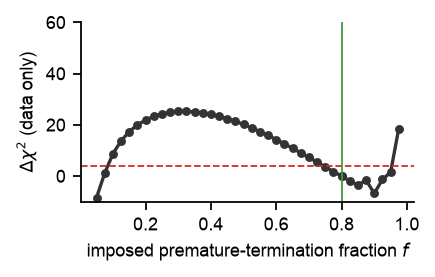

In [7]:
i0 = pm.cost(REF, data, full=True)
SSE0, SIG2 = i0["sse"], i0["sse"] / (i0["n_eff"] - 5)
rows = []
for direction in (np.arange(0.80, 0.991, 0.025), np.arange(0.80, 0.049, -0.025)):
    x = REF.copy()                       # walk outwards from f = 0.8 both ways
    for f in np.round(direction, 3):
        r = pm.fit(data, n_starts=6, seed=13, x0=x, pt_fraction=f)
        x = r["params"]
        i2 = pm.cost(x, data, full=True, pt_fraction=f)
        s_np, s_pe = pm.saturation(1.0, x)
        rows.append(dict(pt_fraction=f, sse=i2["sse"],
                         dchi2=(i2["sse"] - SSE0) / SIG2, s_np=s_np, s_pe=s_pe,
                         T_low=pm.buffering_range(x)[0], S_T1=pm.log_sensitivity(x),
                         k_pn=x[0], at_kpn_bound=abs(x[0] - pm.BOUNDS[0][1]) < 1e-3))
pt_prof = pd.DataFrame(rows).sort_values("pt_fraction")
pt_prof.to_csv("table_pt_profile.csv", index=False)
print(pt_prof.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7 / 2.54, 4.5 / 2.54))
ax.plot(pt_prof.pt_fraction, pt_prof.dchi2, "o-", ms=3, color="#333333")
ax.axhline(3.841, color="#d62728", lw=0.8, ls="--")
ax.axvline(0.8, color="#419c46", lw=0.8)
ax.set_xlabel("imposed premature-termination fraction $f$")
ax.set_ylabel(r"$\Delta\chi^2$ (data only)")
ax.set_ylim(-10, 60)
fig.tight_layout(); fig.savefig("fig_pt_profile.pdf")

In [8]:
free = pm.fit(data, n_starts=60, seed=3, x0=REF, constraint_weight=0.0)
s_free = pm.summarise(free["params"], data, constraint_weight=0.0)
s_free["pt_achieved"] = pm.cost(free["params"], data, full=True,
                                constraint_weight=0.0)["pt_achieved"]
print("Constraint removed entirely:")
print(pd.Series(s_free).round(3).to_string())

Constraint removed entirely:
k_pn           0.010
Vmax_pe        0.344
Km_pe          0.034
Vmax_np        0.331
Km_np          0.028
N0             0.407
P0             0.286
E0             0.307
s_np_T0.5      0.807
s_pe_T0.5      0.774
s_np_T0.7      0.886
s_pe_T0.7      0.848
s_np_T1.0      0.936
s_pe_T1.0      0.893
T_low          0.702
T_high           NaN
S_T1           0.102
cost           0.002
pt_achieved    0.009


## 3. Joint grid

In [9]:
t0, rows = time.time(), []
for f in [0.5, 0.6, 0.7, 0.8, 0.9]:
    x = REF.copy()
    for v in [1, 2, 3, 5, 10]:
        # warm start from the neighbouring grid cell as well as random starts,
        # so a single unlucky local optimum cannot create a false kink
        r = pm.fit(data, n_starts=12, seed=5, x0=x, pt_fraction=f, w_P=float(v))
        x = r["params"]
        s = pm.summarise(x, data, pt_fraction=f, w_P=float(v))
        rows.append({**s, "pt_fraction": f, "w_P": v})
    print("PT", f, flush=True)
grid = pd.DataFrame(rows)
grid.to_csv("table_joint_grid.csv", index=False)
print(f"{time.time()-t0:.0f} s")

PT 0.5
PT 0.6
PT 0.7
PT 0.8
PT 0.9
537 s


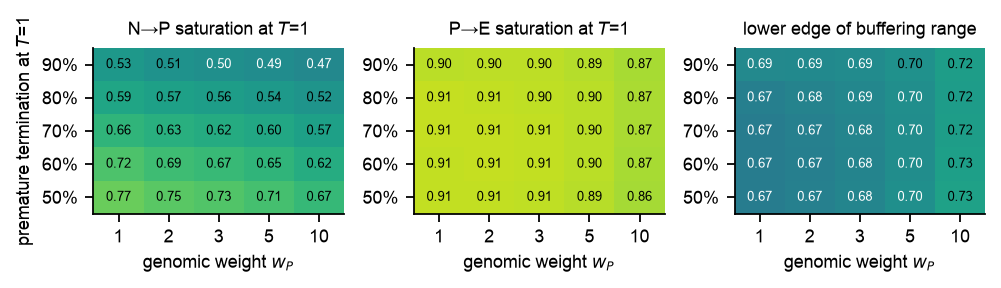

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16 / 2.54, 4.6 / 2.54))
for ax, (c, lab, vlim) in zip(axes, [
        ("s_np_T1.0", "N→P saturation at $T$=1", (0, 1)),
        ("s_pe_T1.0", "P→E saturation at $T$=1", (0, 1)),
        ("T_low", "lower edge of buffering range", (0.5, 0.9))]):
    m = grid.pivot(index="pt_fraction", columns="w_P", values=c)
    im = ax.imshow(m.values, origin="lower", cmap="viridis", aspect="auto",
                   vmin=vlim[0], vmax=vlim[1])
    ax.set_xticks(range(len(m.columns)), m.columns)
    ax.set_yticks(range(len(m.index)), [f"{i:.0%}" for i in m.index])
    ax.set_xlabel("genomic weight $w_P$"); ax.set_title(lab, fontsize=8)
    for (i, j), v in np.ndenumerate(m.values):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                color="w" if v < (vlim[0] + vlim[1]) / 2 else "k")
axes[0].set_ylabel("premature termination at $T$=1")
fig.tight_layout(); fig.savefig("fig_joint_grid.pdf")

## 4. Summary figure

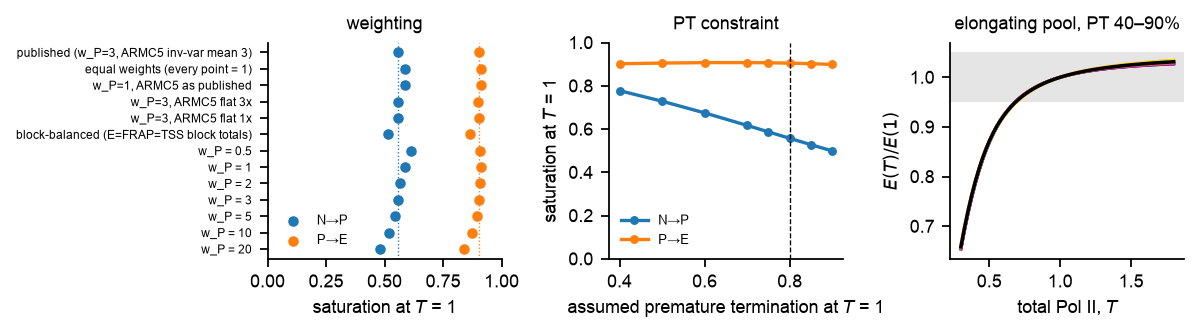

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19 / 2.54, 5.4 / 2.54))

ax = axes[0]
y = np.arange(len(weighting))[::-1]
ax.scatter(weighting["s_np_T1.0"], y, s=14, color="#1f77b4", label="N→P")
ax.scatter(weighting["s_pe_T1.0"], y, s=14, color="#ff7f0e", label="P→E")
ax.set_yticks(y, weighting["label"], fontsize=5.5)
ax.set_xlim(0, 1); ax.set_xlabel("saturation at $T$ = 1")
ax.axvline(weighting["s_np_T1.0"].iloc[0], color="#1f77b4", lw=0.6, ls=":")
ax.axvline(weighting["s_pe_T1.0"].iloc[0], color="#ff7f0e", lw=0.6, ls=":")
ax.legend(frameon=False, fontsize=6, loc="lower left")
ax.set_title("weighting", fontsize=8)

ax = axes[1]
ax.plot(pt["pt_fraction"], pt["s_np_T1.0"], "o-", ms=3, color="#1f77b4", label="N→P")
ax.plot(pt["pt_fraction"], pt["s_pe_T1.0"], "o-", ms=3, color="#ff7f0e", label="P→E")
ax.axvline(0.8, color="k", lw=0.6, ls="--")
ax.set_ylim(0, 1); ax.set_xlabel("assumed premature termination at $T$ = 1")
ax.set_ylabel("saturation at $T$ = 1"); ax.legend(frameon=False, fontsize=6)
ax.set_title("PT constraint", fontsize=8)

ax = axes[2]
T = np.linspace(0.3, 1.8, 60)
E_ref = np.array([pm.steady_state(t, REF)[2] for t in T]) / pm.steady_state(1, REF)[2]
for f, p in zip(pt["pt_fraction"], pt[pm.PARAM_NAMES].values):
    E = np.array([pm.steady_state(t, p)[2] for t in T]) / pm.steady_state(1, p)[2]
    ax.plot(T, E, lw=1.4, color=plt.cm.plasma((f - 0.35) / 0.6))
ax.plot(T, E_ref, lw=1.6, color="k")
ax.axhspan(0.95, 1.05, color="#cccccc", alpha=0.5, lw=0)
ax.set_xlabel("total Pol II, $T$"); ax.set_ylabel("$E(T)/E(1)$")
ax.set_title("elongating pool, PT 40–90%", fontsize=8)
fig.tight_layout(w_pad=1.6); fig.savefig("fig_weighting_pt_summary.pdf")

## 5. Ranges across every fit performed here

In [12]:
allfits = pd.concat([weighting.assign(analysis="weighting"),
                     pt.assign(analysis="PT fraction"),
                     grid.assign(analysis="joint grid")], ignore_index=True)
rng_tab = allfits.groupby("analysis")[
    ["s_np_T1.0", "s_pe_T1.0", "T_low", "S_T1"]].agg(["min", "max"])
print(rng_tab.round(3).to_string())
print("\nacross ALL refits: s_NP %.2f-%.2f, s_PE %.2f-%.2f, "
      "s_PE > s_NP in %d/%d fits" % (
          allfits["s_np_T1.0"].min(), allfits["s_np_T1.0"].max(),
          allfits["s_pe_T1.0"].min(), allfits["s_pe_T1.0"].max(),
          (allfits["s_pe_T1.0"] > allfits["s_np_T1.0"]).sum(), len(allfits)))
allfits.to_csv("table_all_sensitivity_fits.csv", index=False)

            s_np_T1.0        s_pe_T1.0         T_low          S_T1       
                  min    max       min    max    min    max    min    max
analysis                                                                 
PT fraction     0.499  0.778     0.899  0.908  0.681  0.693  0.083  0.096
joint grid      0.467  0.772     0.865  0.912  0.667  0.730  0.073  0.123
weighting       0.481  0.611     0.837  0.912  0.672  0.749  0.079  0.146

across ALL refits: s_NP 0.47-0.78, s_PE 0.84-0.91, s_PE > s_NP in 46/46 fits
